# EDA FD003 - patrones de degradacion

Objetivo: estudiar si FD003, que tiene una sola condicion operativa y dos modos de falla declarados, muestra subgrupos de motores con patrones de degradacion distintos.

Importante: el dataset no trae una etiqueta de fault mode por motor. Por eso este notebook no clasifica fallas reales; solo genera una hipotesis exploratoria mediante clustering no supervisado.


## 1. Setup


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import SENSOR_COLUMNS, SETTING_COLUMNS, add_train_rul, last_cycle_rows, load_cmapss_subset
from src.eda import dataset_overview

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42


## 2. Carga de FD003

FD003 mantiene una sola condicion operativa, como FD001, pero incorpora dos modos de falla. Esto lo vuelve el subset mas limpio para explorar posibles patrones de falla sin la confusion de multiples regimes operativos.


In [2]:
data = load_cmapss_subset("FD003", data_dir=PROJECT_ROOT / "CMAPSSData")
train = add_train_rul(data.train)
test_last = last_cycle_rows(data.test).merge(data.rul, on="unit", how="left")

overview = dataset_overview(data.train, data.test, data.rul)
overview


,dataset,rows,columns,units,missing_values,duplicated_rows
0,train,24720,26,100,0,0
1,test,16596,26,100,0,0
2,rul,100,2,100,0,0


In [3]:
setting_summary = train[SETTING_COLUMNS].agg(["mean", "std", "min", "max"]).T
setting_summary


,mean,std,min,max
setting_1,-0.0000,0.0022,-0.0086,0.0086
setting_2,0.0000,0.0003,-0.0006,0.0007
setting_3,100.0000,0.0000,100.0000,100.0000


## 3. Chequeo de cap de RUL en FD003

El cap de RUL es una decision de modelado posible. En FD003 afecta bastante al target porque muchas filas de train corresponden a etapas tempranas de motores con vida util larga.


In [4]:
RUL_CAP = 125

fd003_rul_cap_summary = pd.DataFrame(
    [
        {
            "split": "train_rows",
            "rows_or_units": len(train),
            "pct_above_cap": (train["RUL"] > RUL_CAP).mean() * 100,
            "rul_mean_raw": train["RUL"].mean(),
            "rul_mean_capped": train["RUL"].clip(upper=RUL_CAP).mean(),
        },
        {
            "split": "test_last_cycle",
            "rows_or_units": len(test_last),
            "pct_above_cap": (test_last["final_rul"] > RUL_CAP).mean() * 100,
            "rul_mean_raw": test_last["final_rul"].mean(),
            "rul_mean_capped": test_last["final_rul"].clip(upper=RUL_CAP).mean(),
        },
    ]
)
fd003_rul_cap_summary


,split,rows_or_units,pct_above_cap,rul_mean_raw,rul_mean_capped
0,train_rows,24720,49.0291,138.0771,93.1432
1,test_last_cycle,100,15.0000,75.3200,73.7600


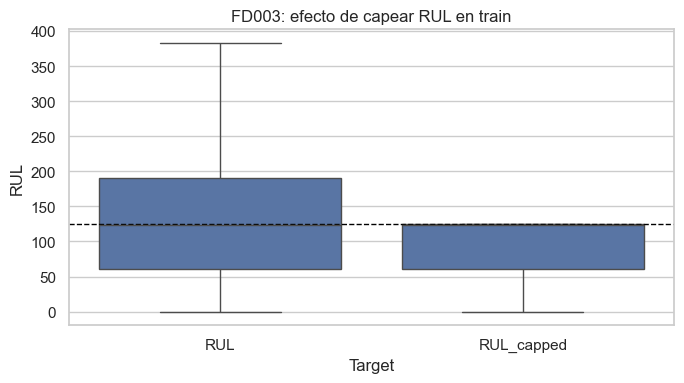

In [5]:
fd003_rul_plot = train[["RUL"]].copy()
fd003_rul_plot["RUL_capped"] = fd003_rul_plot["RUL"].clip(upper=RUL_CAP)
fd003_rul_plot = fd003_rul_plot.melt(var_name="target", value_name="rul")

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=fd003_rul_plot, x="target", y="rul", ax=ax, showfliers=False)
ax.axhline(RUL_CAP, color="black", linestyle="--", linewidth=1)
ax.set_title("FD003: efecto de capear RUL en train")
ax.set_xlabel("Target")
ax.set_ylabel("RUL")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd003_rul_cap_effect.png", dpi=150)
plt.show()


## 4. Firma de degradacion por motor

Para comparar motores completos, cada trayectoria se resume con una firma por motor: valores iniciales, finales, deltas y slopes de sensores. Tambien se conservan estadisticas de settings para verificar si los clusters se explican por condicion operativa.


In [6]:
def unit_degradation_signature(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for unit, group in df.sort_values(["unit", "cycle"]).groupby("unit"):
        life_cycles = group["cycle"].max()
        first_window = group.head(min(5, len(group)))
        last_window = group.tail(min(5, len(group)))

        row = {"unit": unit, "life_cycles": life_cycles}
        for column in SENSOR_COLUMNS:
            start = first_window[column].mean()
            end = last_window[column].mean()
            row[f"{column}_start"] = start
            row[f"{column}_end"] = end
            row[f"{column}_delta"] = end - start
            row[f"{column}_slope"] = (end - start) / life_cycles

        for column in SETTING_COLUMNS:
            row[f"{column}_mean"] = group[column].mean()
            row[f"{column}_std"] = group[column].std()

        rows.append(row)

    return pd.DataFrame(rows)


signature = unit_degradation_signature(train)
signature.head()


,unit,life_cycles,sensor_1_start,sensor_1_end,sensor_1_delta,sensor_1_slope,sensor_2_start,sensor_2_end,sensor_2_delta,sensor_2_slope,sensor_3_start,sensor_3_end,sensor_3_delta,sensor_3_slope,sensor_4_start,sensor_4_end,sensor_4_delta,sensor_4_slope,sensor_5_start,sensor_5_end,sensor_5_delta,sensor_5_slope,sensor_6_start,sensor_6_end,sensor_6_delta,sensor_6_slope,sensor_7_start,sensor_7_end,sensor_7_delta,sensor_7_slope,sensor_8_start,sensor_8_end,sensor_8_delta,sensor_8_slope,sensor_9_start,sensor_9_end,sensor_9_delta,sensor_9_slope,sensor_10_start,sensor_10_end,sensor_10_delta,sensor_10_slope,sensor_11_start,sensor_11_end,sensor_11_delta,sensor_11_slope,sensor_12_start,sensor_12_end,sensor_12_delta,sensor_12_slope,sensor_13_start,sensor_13_end,sensor_13_delta,sensor_13_slope,sensor_14_start,sensor_14_end,sensor_14_delta,sensor_14_slope,sensor_15_start,sensor_15_end,sensor_15_delta,sensor_15_slope,sensor_16_start,sensor_16_end,sensor_16_delta,sensor_16_slope,sensor_17_start,sensor_17_end,sensor_17_delta,sensor_17_slope,sensor_18_start,sensor_18_end,sensor_18_delta,sensor_18_slope,sensor_19_start,sensor_19_end,sensor_19_delta,sensor_19_slope,sensor_20_start,sensor_20_end,sensor_20_delta,sensor_20_slope,sensor_21_start,sensor_21_end,sensor_21_delta,sensor_21_slope,setting_1_mean,setting_1_std,setting_2_mean,setting_2_std,setting_3_mean,setting_3_std
0,1,259,518.6700,518.6700,0.0000,0.0000,642.3280,643.6720,1.3440,0.0052,"1,584.9020","1,601.3780",16.4760,0.0636,"1,397.8520","1,428.5120",30.6600,0.1184,14.6200,14.6200,0.0000,0.0000,21.6100,21.6100,0.0000,0.0000,554.5800,551.7320,-2.8480,-0.0110,"2,388.0060","2,388.2560",0.2500,0.0010,"9,066.9780","9,077.5580",10.5800,0.0408,1.3000,1.3000,0.0000,0.0000,47.2280,48.1800,0.9520,0.0037,522.3660,519.8120,-2.5540,-0.0099,"2,388.0300","2,388.2280",0.1980,0.0008,"8,148.5400","8,148.7700",0.2300,0.0009,8.4059,8.5161,0.1102,0.0004,0.0300,0.0300,0.0000,0.0000,391.6000,396.6000,5.0000,0.0193,"2,388.0000","2,388.0000",0.0000,0.0000,100.0000,100.0000,0.0000,0.0000,39.0100,38.4100,-0.6000,-0.0023,23.3846,23.0725,-0.3121,-0.0012,0.0001,0.0024,-0.0000,0.0003,100.0000,0.0000
1,2,253,518.6700,518.6700,0.0000,0.0000,642.0720,643.1880,1.1160,0.0044,"1,582.8600","1,599.9860",17.1260,0.0677,"1,393.7720","1,423.3320",29.5600,0.1168,14.6200,14.6200,0.0000,0.0000,21.5780,21.5800,0.0020,0.0000,553.6660,568.2580,14.5920,0.0577,"2,387.9520","2,388.4820",0.5300,0.0021,"9,050.6140","9,123.8200",73.2060,0.2894,1.3000,1.3120,0.0120,0.0000,47.0800,48.0860,1.0060,0.0040,521.6460,535.5000,13.8540,0.0548,"2,387.9680","2,388.5200",0.5520,0.0022,"8,135.9020","8,188.2060",52.3040,0.2067,8.3709,8.2499,-0.1210,-0.0005,0.0300,0.0300,0.0000,0.0000,391.0000,396.4000,5.4000,0.0213,"2,388.0000","2,388.0000",0.0000,0.0000,100.0000,100.0000,0.0000,0.0000,39.0020,39.6280,0.6260,0.0025,23.3989,23.7885,0.3896,0.0015,0.0001,0.0024,0.0000,0.0003,100.0000,0.0000
2,3,222,518.6700,518.6700,0.0000,0.0000,642.2760,643.8840,1.6080,0.0072,"1,585.3420","1,600.6480",15.3060,0.0689,"1,396.8200","1,429.7440",32.9240,0.1483,14.6200,14.6200,0.0000,0.0000,21.6060,21.6100,0.0040,0.0000,554.7160,551.4600,-3.2560,-0.0147,"2,388.0220","2,388.2320",0.2100,0.0009,"9,055.0480","9,089.3180",34.2700,0.1544,1.3000,1.3000,0.0000,0.0000,47.2940,48.0880,0.7940,0.0036,522.2060,519.8440,-2.3620,-0.0106,"2,388.0200","2,388.2240",0.2040,0.0009,"8,137.2580","8,160.5580",23.3000,0.1050,8.3861,8.5116,0.1255,0.0006,0.0300,0.0300,0.0000,0.0000,391.4000,396.0000,4.6000,0.0207,"2,388.0000","2,388.0000",0.0000,0.0000,100.0000,100.0000,0.0000,0.0000,39.0120,38.3560,-0.6560,-0.0030,23.4168,23.0990,-0.3178,-0.0014,0.0002,0.0023,0.0001,0.0003,100.0000,0.0000
3,4,272,518.6700,518.6700,0.0000,0.0000,642.5940,643.6860,1.0920,0.0040,"1,589.0460","1,601.0040",11.9580,0.0440,"1,412.2040","1,427.8120",15.6080,0.0574,14.6200,14.6200,0.0000,0.0000,21.6100,21.6100,0.0000,0.0000,553.2980,550.8480,-2.4500,-0.0090,"2,388.0960","2,388.3000",0.2040,0.0008,"9,049.1040","9,049.3060",0.2020,0.

## 5. Clustering inicial

Se prueba `KMeans(k=2)` porque FD003 tiene dos modos de falla declarados. La interpretacion sigue siendo exploratoria: dos clusters no equivalen automaticamente a dos fault modes reales.


In [7]:
sensor_signature_cols = [
    column
    for column in signature.columns
    if column.endswith("_end") or column.endswith("_delta") or column.endswith("_slope")
]

X = StandardScaler().fit_transform(signature[sensor_signature_cols])
cluster = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=30).fit_predict(X)
signature["cluster"] = cluster
silhouette = silhouette_score(X, cluster)

cluster_summary = (
    signature.groupby("cluster")
    .agg(
        units=("unit", "count"),
        life_cycles_mean=("life_cycles", "mean"),
        setting_1_mean=("setting_1_mean", "mean"),
        setting_2_mean=("setting_2_mean", "mean"),
        setting_3_mean=("setting_3_mean", "mean"),
    )
    .reset_index()
)
cluster_summary["silhouette"] = silhouette
cluster_summary


,cluster,units,life_cycles_mean,setting_1_mean,setting_2_mean,setting_3_mean,silhouette
0,0,44,304.6591,-0.0000,0.0000,100.0000,0.4826
1,1,56,202.0536,-0.0000,0.0000,100.0000,0.4826


In [8]:
cluster_means = signature.groupby("cluster")[sensor_signature_cols].mean()
top_cluster_gaps = (
    (cluster_means.loc[1] - cluster_means.loc[0])
    .abs()
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
)
top_cluster_gaps.columns = ["feature", "abs_gap"]
top_cluster_gaps


,feature,abs_gap
0,sensor_9_delta,37.1858
1,sensor_14_delta,33.3496
2,sensor_9_end,30.0213
3,sensor_14_end,29.4234
4,sensor_7_end,16.7120
5,sensor_7_delta,16.7021
6,sensor_12_delta,15.8136
7,sensor_12_end,15.7576
8,sensor_3_delta,5.5068
9,sensor_4_end,4.2320


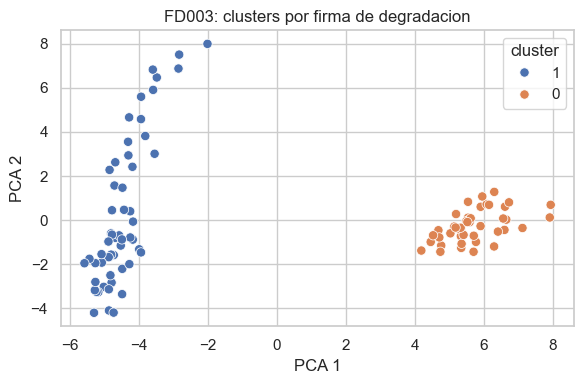

In [9]:
pca_coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
pca_plot = pd.DataFrame(pca_coords, columns=["pc1", "pc2"])
pca_plot["cluster"] = cluster.astype(str)

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=pca_plot, x="pc1", y="pc2", hue="cluster", ax=ax, s=45)
ax.set_title("FD003: clusters por firma de degradacion")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend(title="cluster")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd003_fault_pattern_clusters_pca.png", dpi=150)
plt.show()


## 6. Trayectorias promedio por cluster

Para validar que los grupos tengan sentido temporal, se comparan trayectorias promedio de los sensores que mas separan los clusters. Se normaliza cada motor entre 0 y 1 de vida observada para poder promediar trayectorias con distinta duracion.


In [10]:
clustered_train = train.merge(signature[["unit", "cluster"]], on="unit", how="left")
clustered_train["max_cycle"] = clustered_train.groupby("unit")["cycle"].transform("max")
clustered_train["life_pct"] = clustered_train["cycle"] / clustered_train["max_cycle"]
clustered_train["life_bin"] = pd.cut(
    clustered_train["life_pct"],
    bins=np.linspace(0, 1, 21),
    include_lowest=True,
    labels=False,
)
clustered_train["life_bin_mid"] = (clustered_train["life_bin"] + 0.5) / 20

key_sensors = ["sensor_9", "sensor_14", "sensor_7"]
cluster_trajectories = (
    clustered_train.groupby(["cluster", "life_bin_mid"], as_index=False)[key_sensors]
    .mean()
)
cluster_trajectories.head()


,cluster,life_bin_mid,sensor_9,sensor_14,sensor_7
0,0,0.0250,"9,049.5837","8,133.7865",553.8578
1,0,0.0750,"9,049.5645","8,133.9630",553.8823
2,0,0.1250,"9,049.8299","8,133.9915",553.8897
3,0,0.1750,"9,050.2614","8,134.2628",553.9351
4,0,0.2250,"9,050.2734","8,134.4732",553.9843


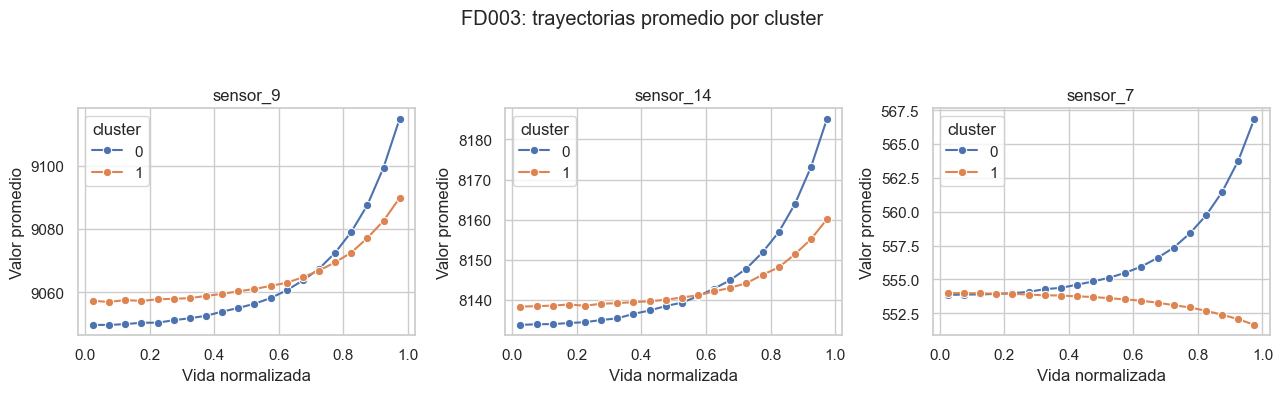

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True)
for ax, sensor in zip(axes, key_sensors):
    sns.lineplot(
        data=cluster_trajectories,
        x="life_bin_mid",
        y=sensor,
        hue="cluster",
        marker="o",
        ax=ax,
    )
    ax.set_title(sensor)
    ax.set_xlabel("Vida normalizada")
    ax.set_ylabel("Valor promedio")

fig.suptitle("FD003: trayectorias promedio por cluster", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig(FIGURES_DIR / "fd003_cluster_sensor_trajectories.png", dpi=150)
plt.show()


## 7. Control: clustering sin slopes

El clustering inicial incluye slopes, que dividen el cambio del sensor por la duracion total del motor. Para verificar que la separacion no dependa solo de esa duracion, se repite el clustering usando solo valores finales y deltas.


In [12]:
no_slope_cols = [
    column
    for column in signature.columns
    if column.endswith("_end") or column.endswith("_delta")
]

X_no_slope = StandardScaler().fit_transform(signature[no_slope_cols])
cluster_no_slope = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=30).fit_predict(X_no_slope)
silhouette_no_slope = silhouette_score(X_no_slope, cluster_no_slope)

signature_no_slope = signature.copy()
signature_no_slope["cluster_no_slope"] = cluster_no_slope

no_slope_summary = (
    signature_no_slope.groupby("cluster_no_slope")
    .agg(
        units=("unit", "count"),
        life_cycles_mean=("life_cycles", "mean"),
        setting_1_mean=("setting_1_mean", "mean"),
        setting_2_mean=("setting_2_mean", "mean"),
        setting_3_mean=("setting_3_mean", "mean"),
    )
    .reset_index()
)
no_slope_summary["silhouette"] = silhouette_no_slope
no_slope_summary


,cluster_no_slope,units,life_cycles_mean,setting_1_mean,setting_2_mean,setting_3_mean,silhouette
0,0,44,304.6591,-0.0000,0.0000,100.0000,0.5211
1,1,56,202.0536,-0.0000,0.0000,100.0000,0.5211


In [13]:
no_slope_means = signature_no_slope.groupby("cluster_no_slope")[no_slope_cols].mean()
no_slope_top_gaps = (
    (no_slope_means.loc[1] - no_slope_means.loc[0])
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
no_slope_top_gaps.columns = ["feature", "abs_gap"]
no_slope_top_gaps


,feature,abs_gap
0,sensor_9_delta,37.1858
1,sensor_14_delta,33.3496
2,sensor_9_end,30.0213
3,sensor_14_end,29.4234
4,sensor_7_end,16.7120
5,sensor_7_delta,16.7021
6,sensor_12_delta,15.8136
7,sensor_12_end,15.7576
8,sensor_3_delta,5.5068
9,sensor_4_end,4.2320


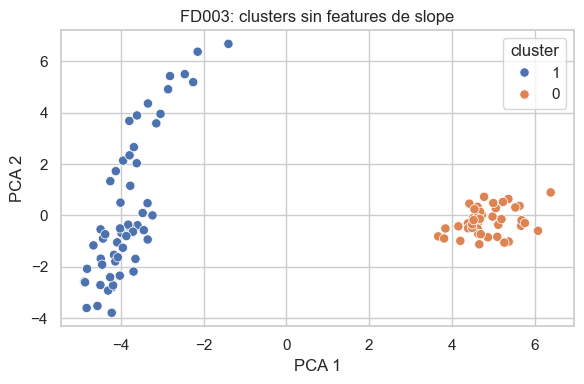

In [14]:
no_slope_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_no_slope)
no_slope_pca = pd.DataFrame(no_slope_pca, columns=["pc1", "pc2"])
no_slope_pca["cluster"] = cluster_no_slope.astype(str)

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=no_slope_pca, x="pc1", y="pc2", hue="cluster", ax=ax, s=45)
ax.set_title("FD003: clusters sin features de slope")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend(title="cluster")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd003_cluster_no_slope_pca.png", dpi=150)
plt.show()


## 8. Lectura final

- FD003 muestra dos clusters de motores claramente separados bajo una unica condicion operativa.
- La separacion no parece explicarse por settings, porque estos son practicamente iguales entre grupos.
- Los sensores que mas separan los grupos son `sensor_9`, `sensor_14` y `sensor_7`.
- Las trayectorias promedio muestran dinamicas distintas: en `sensor_7`, un grupo aumenta hacia el final y el otro disminuye.
- El control sin slopes mantiene la separacion y mejora el silhouette aproximado a 0.52.
- Esto sugiere dos patrones de degradacion compatibles con los dos fault modes declarados, pero no permite afirmar etiquetas reales de falla.
- Uso recomendado: analizar despues los errores del modelo FD003 por cluster.
